In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('DailyDelhiClimateTrain.csv', index_col='date', parse_dates=True)
df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1462 entries, 2013-01-01 to 2017-01-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1462 non-null   float64
 1   humidity      1462 non-null   float64
 2   wind_speed    1462 non-null   float64
 3   meanpressure  1462 non-null   float64
dtypes: float64(4)
memory usage: 57.1 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
meantemp,1462.0,25.495521,7.348103,6.000000,18.857143,27.714286,31.305804,38.714286
humidity,1462.0,60.771702,16.769652,13.428571,50.375000,62.625000,72.218750,100.000000
wind_speed,1462.0,6.802209,4.561602,0.000000,3.475000,6.221667,9.238235,42.220000
meanpressure,1462.0,1011.104548,180.231668,-3.041667,1001.580357,1008.563492,1014.944901,7679.333333


<Axes: xlabel='date', ylabel='meantemp'>

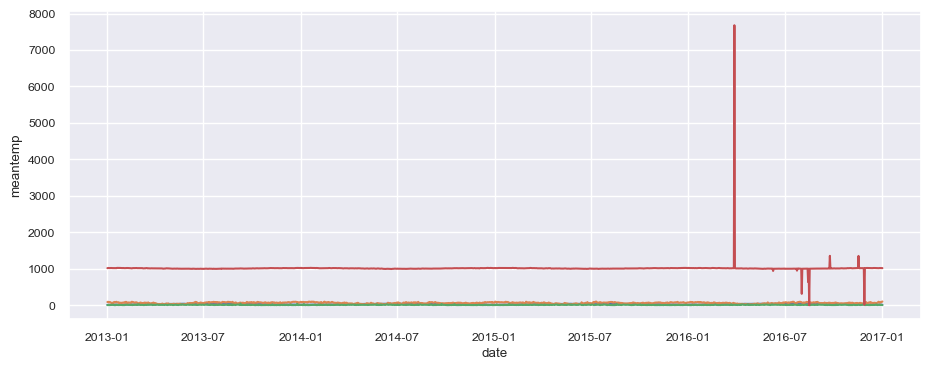

In [5]:
# Draw a line plot
sns.set(rc={'figure.figsize':(11,4)}, font_scale=0.8, style='darkgrid')
sns.lineplot(data=df, x='date', y='meantemp')
sns.lineplot(data=df, x='date', y='humidity')
sns.lineplot(data=df, x='date', y='wind_speed')
sns.lineplot(data=df, x='date', y='meanpressure')

<Axes: xlabel='date', ylabel='meantemp'>

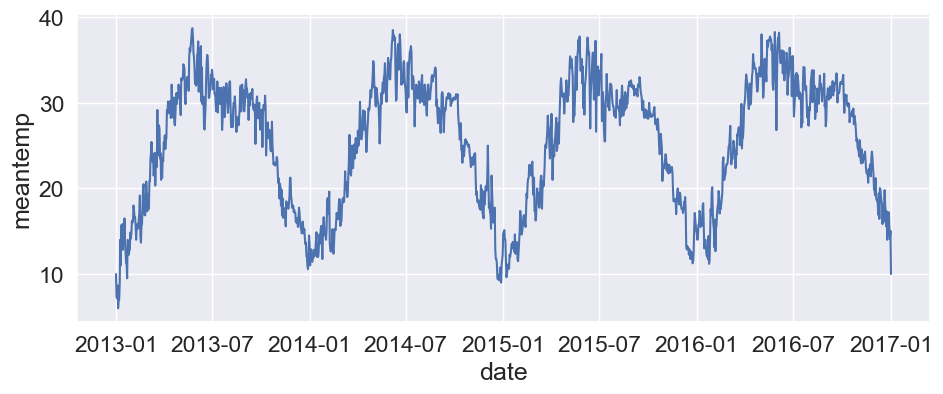

In [6]:
# Draw the plot
sns.set(rc={'figure.figsize':(11,4)}, font_scale=1.5, style='darkgrid')
sns.lineplot(data=df, x='date', y='meantemp')

In [7]:
# Draw same plot on plotly
fig = px.line(df, x=df.index, y='meantemp', title='Mean Temperature')
fig.show()

In [8]:
import scipy
import statsmodels
import plotly

print("SciPy:", scipy.__version__)
print("Statsmodels:", statsmodels.__version__)
print("Plotly:", plotly.__version__)

SciPy: 1.15.3
Statsmodels: 0.14.4
Plotly: 6.7.0


In [9]:
import sys
print(sys.executable)

D:\anaconda3\python.exe


In [10]:
# Make a scatter plot b/w Mean Temperature and Humidity
import plotly.express as px

fig = px.scatter(
    df,
    x='meantemp',
    y='humidity',
    title='Mean Temperature vs Humidity',
    trendline='ols',
    trendline_color_override='red'
)

fig.show()

In [11]:
from scipy.stats import pearsonr
corr, _ = pearsonr(df['meantemp'], df['humidity'])
print('Pearsons correleation : ', corr)

Pearsons correleation :  -0.5719507155817221


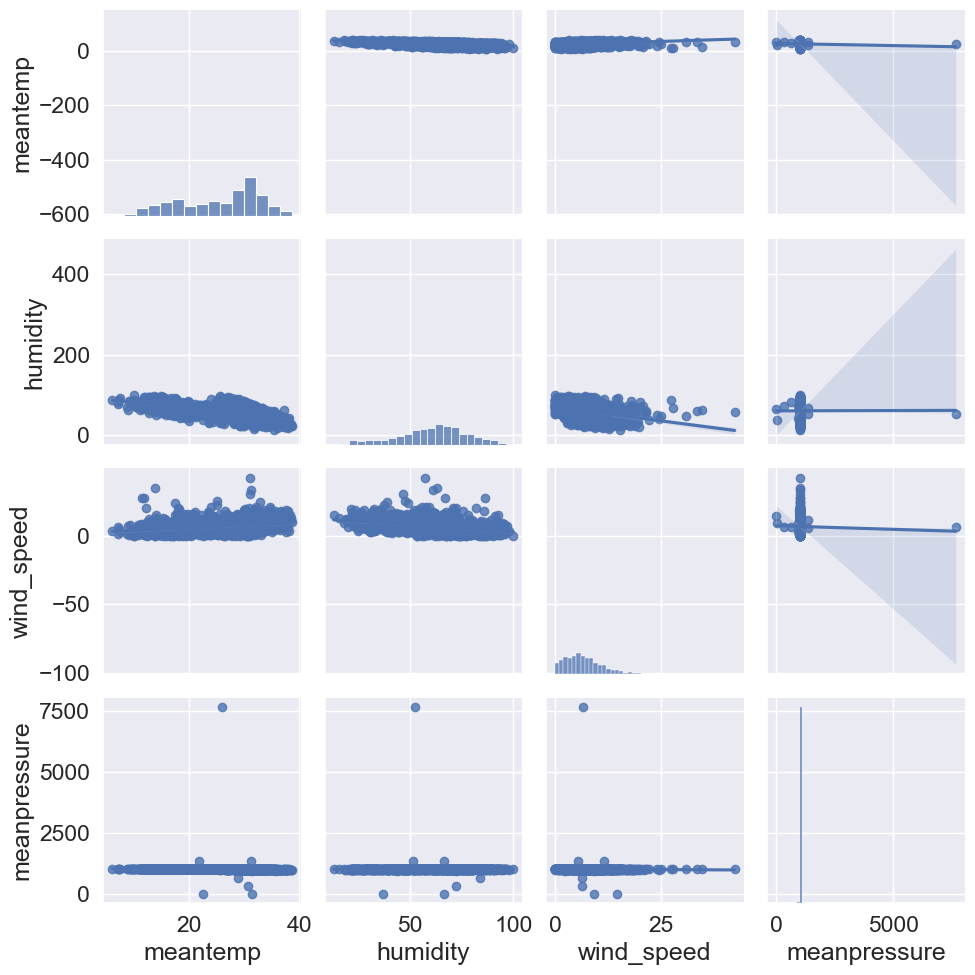

In [12]:
sns.pairplot(df, kind='reg')

<Axes: >

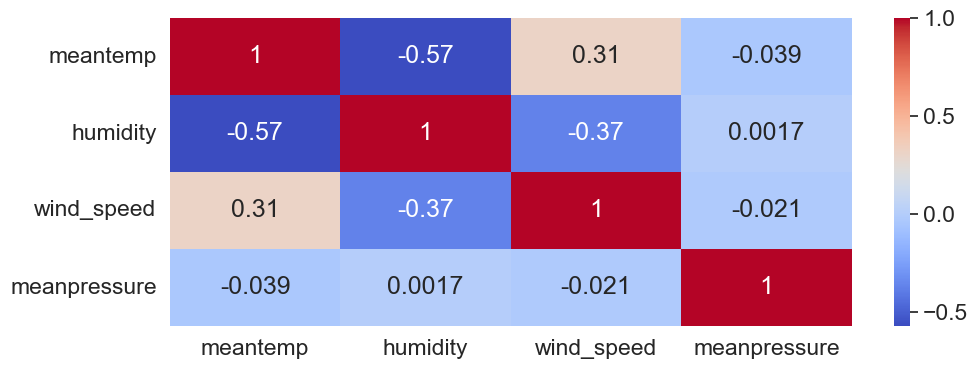

In [13]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [14]:
# Let's scale the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
df_scaled.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,0.595933,0.546868,0.161113,0.132009
std,0.224614,0.193709,0.108044,0.023460
min,0.000000,0.000000,0.000000,0.000000
25%,0.393013,0.426774,0.082307,0.130770
50%,0.663755,0.568276,0.147363,0.131679
75%,0.773540,0.679094,0.218812,0.132509
max,1.000000,1.000000,1.000000,1.000000


<Axes: >

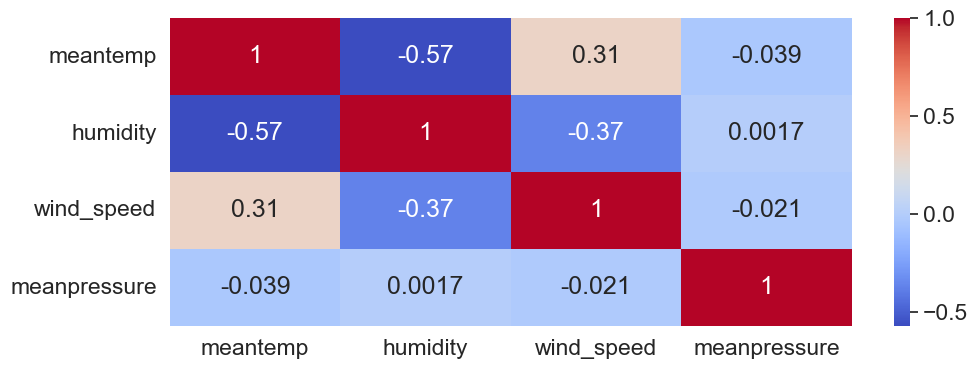

In [15]:
# make a correlation heatmap of scaled data
sns.heatmap(df_scaled.corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='date', ylabel='meantemp'>

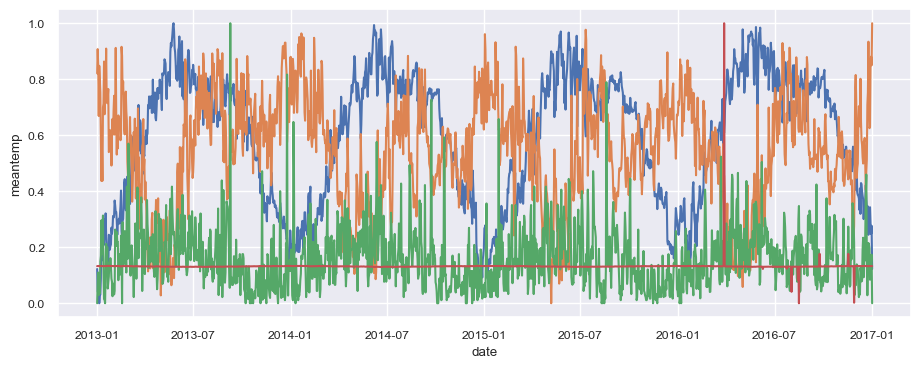

In [16]:
# Draw a line plot
sns.set(rc={'figure.figsize':(11,4)}, font_scale=0.8, style='darkgrid')
sns.lineplot(data=df_scaled, x='date', y='meantemp')
sns.lineplot(data=df_scaled, x='date', y='humidity')
sns.lineplot(data=df_scaled, x='date', y='wind_speed')
sns.lineplot(data=df_scaled, x='date', y='meanpressure')